# SEA-AD Paired Diagnostics

Quality checks on the HVG/HVP files produced by `scripts/run_seaad_hvg_selection.py`:

- `seaad_paired_rna_hvg.h5ad` â€” ~138k cells Ã— 500 HVGs (raw counts)
- `seaad_paired_atac_hvp.h5ad` â€” ~138k cells Ã— 10k HVPs (raw counts)

Both files carry the full SEA-AD `obs` (with object-typed columns coerced to strings for h5py compatibility) plus `cell_type` mirrored from `Subclass`. Useful columns include `Donor ID`, `Sex`, `Age at Death`, `APOE4 Status`, `Overall AD neuropathological Change`, `Cognitive Status`, `Braak`, `CERAD score`, `Thal`, `Continuous Pseudo-progression Score`, `LATE`, `Highest Lewy Body Disease`.

Best run from the project root on a machine that already has the files (e.g. a Jupyter session on the HPC). Subsamples for UMAP are sized to fit a single workstation; full-data UMAP would take significantly longer.

In [1]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=80, facecolor="white")

DATA_DIR = Path("data/processed/seaad")
RNA_HVG  = DATA_DIR / "seaad_paired_rna_hvg.h5ad"
ATAC_HVP = DATA_DIR / "seaad_paired_atac_hvp.h5ad"

for p in (RNA_HVG, ATAC_HVP):
    assert p.exists(), f"missing input: {p}"

In [2]:
rna  = ad.read_h5ad(RNA_HVG)
atac = ad.read_h5ad(ATAC_HVP)
print("RNA :", rna.shape)
print("ATAC:", atac.shape)
print("obs columns:", list(rna.obs.columns))
rna.obs.head(3)

RNA : (138118, 500)
ATAC: (138118, 10000)
obs columns: ['sample_id', 'Neurotypical reference', 'Donor ID', 'Organism', 'Brain Region', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'PMI', 'Fresh Brain Weight', 'Brain pH', 'Overall AD neuropathological Change', 'Thal', 'Braak', 'CERAD score', 'Overall CAA Score', 'Highest Lewy Body Disease', 'Total Microinfarcts (not observed grossly)', 'Total microinfarcts in screening sections', 'Atherosclerosis', 'Arteriolosclerosis', 'LATE', 'Cognitive Status', 'Last CASI Score', 'Interval from last CASI in months', 'Last MMSE Score', 'Interval from last MMSE in months', 'Last MOCA Score', 'Interval from last MOCA in months',

,sample_id,Neurotypical reference,Donor ID,Organism,Brain Region,Sex,Gender,Age at Death,Race (choice=White),Race (choice=Black/ African American),...,Class confidence,Class,Subclass confidence,Subclass,Supertype confidence,Supertype (non-expanded),Supertype,Continuous Pseudo-progression Score,Severely Affected Donor,cell_type
exp_component_name,,,,,,,,,,,,,,,,,,,,,
AAACAGCCAAACATAG-L8XR_210916_02_B11-1131607954,AAACAGCCAAACATAG-L8XR_210916_02_B11-1131607954,False,H21.33.003,human,Human MTG,Male,Male,78.0,Unchecked,Unchecked,...,1.0,Neuronal: Glutamatergic,1.0,L5 IT,0.999407,L5 IT_5,L5 IT_5,0.238033,N,L5 IT
AAACAGCCAAACTGCC-L8XR_210722_01_H07-1122543705,AAACAGCCAAACTGCC-L8XR_210722_01_H07-1122543705,False,H20.33.013,human,Human MTG,Male,Male,94.0,Checked,Unchecked,...,1.0,Neuronal: Glutamatergic,1.0,L6 IT,1.000000,L6 IT_2,L6 IT_2,0.847210,N,L6 IT
AAACAGCCAAAGCTCC-L8XR_211007_02_C04-1135704089,AAACAGCCAAAGCTCC-L8XR_211007_02_C04-1135704089,False,H20.33.005,human,Human MTG,Female,Female,99.0,Checked,Unchecked,...,1.0,Neuronal: Glutamatergic,1.0,L5 IT,1.000000,L5 IT_1,L5 IT_1,0.760781,N,L5 IT


## Cell-level distributions

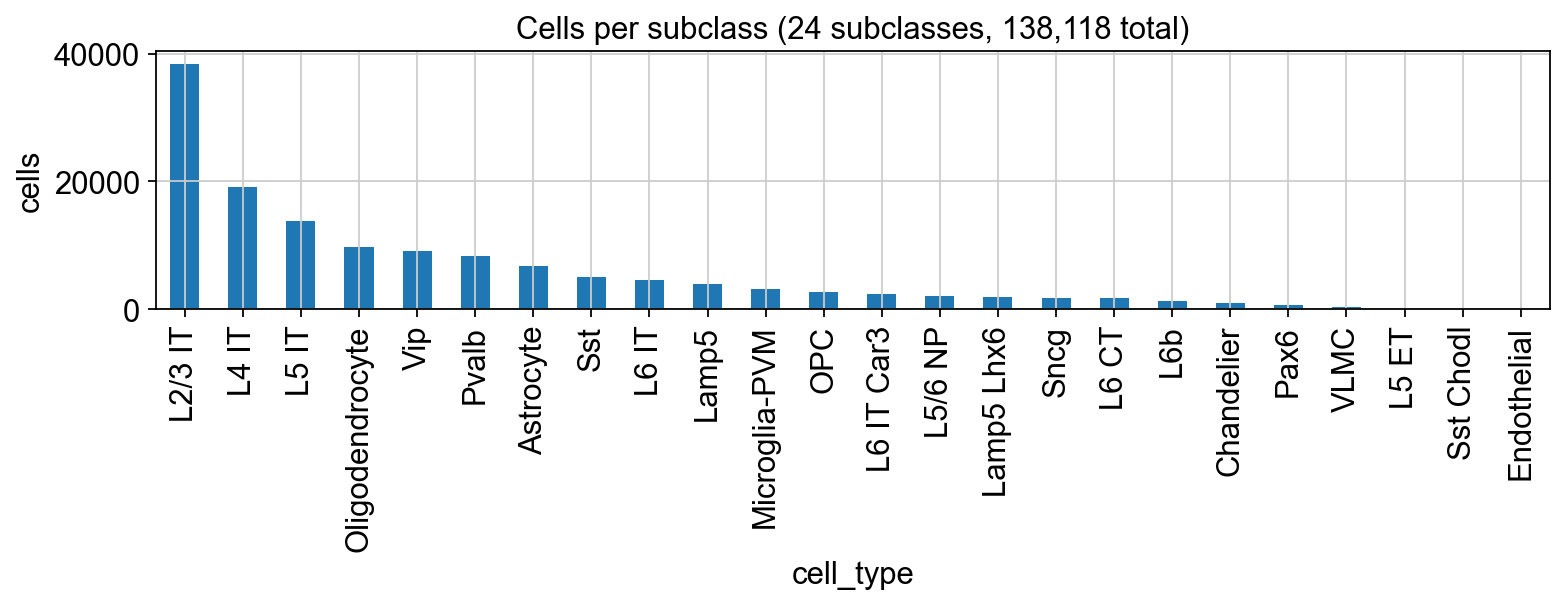

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
rna.obs["cell_type"].value_counts().plot(kind="bar", ax=ax)
ax.set_ylabel("cells")
ax.set_title(f"Cells per subclass ({rna.obs['cell_type'].nunique()} subclasses, {rna.n_obs:,} total)")
plt.tight_layout()

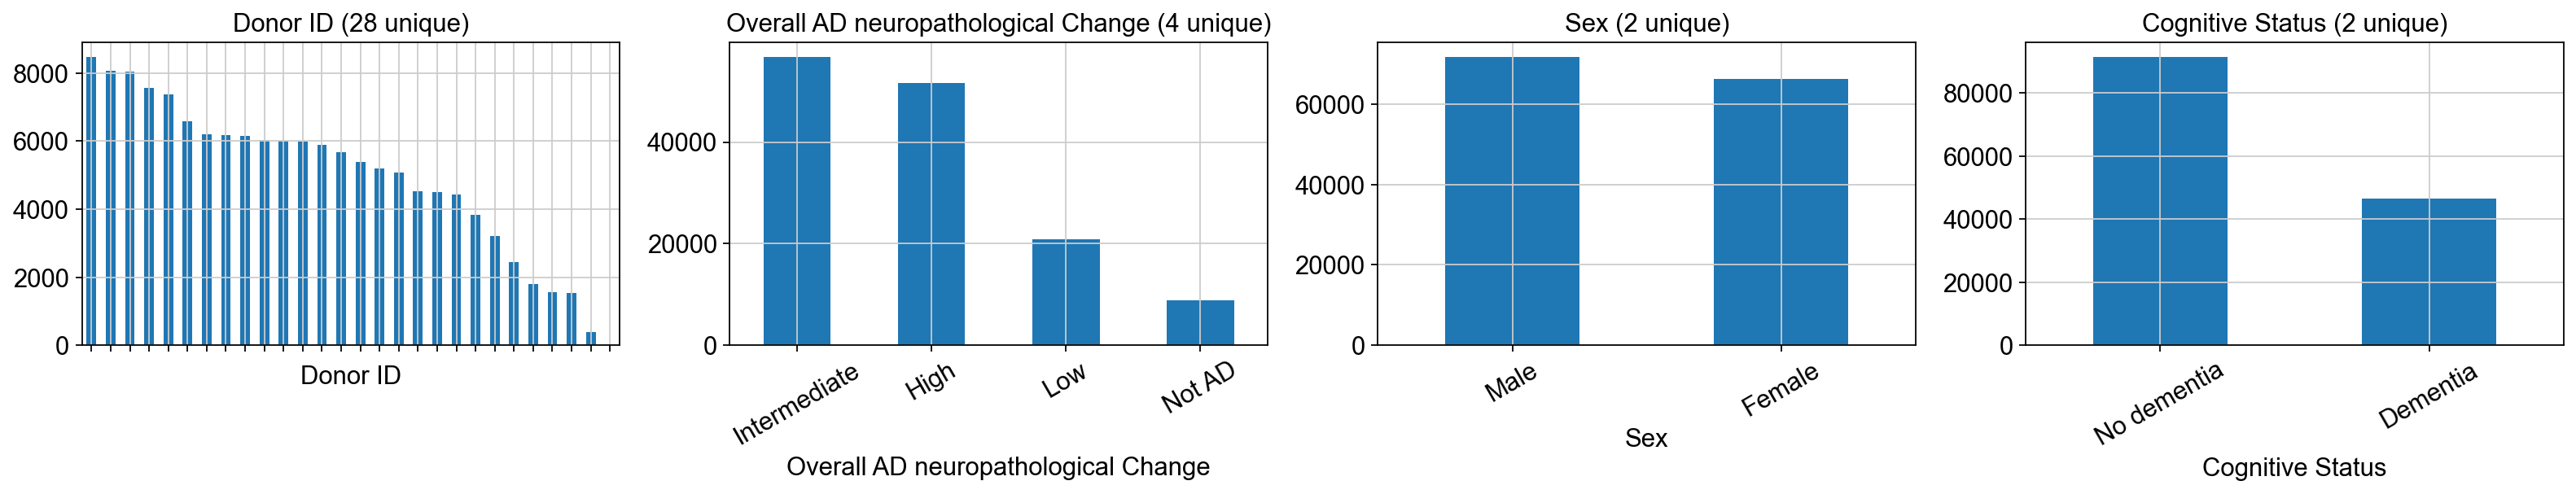

In [4]:
metadata_cols = [c for c in ("Donor ID", "Overall AD neuropathological Change",
                              "Sex", "APOE4 Status", "Cognitive Status") if c in rna.obs.columns]
n = len(metadata_cols)
if n:
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, metadata_cols):
        vc = rna.obs[col].value_counts(dropna=False)
        vc.plot(kind="bar", ax=ax)
        ax.set_title(f"{col} ({len(vc)} unique)")
        if col == "Donor ID":
            ax.set_xticklabels([])
        else:
            ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()

## QC: counts per cell

RNA  median: total=440, detected=67
ATAC median: total=4,513, detected=1347


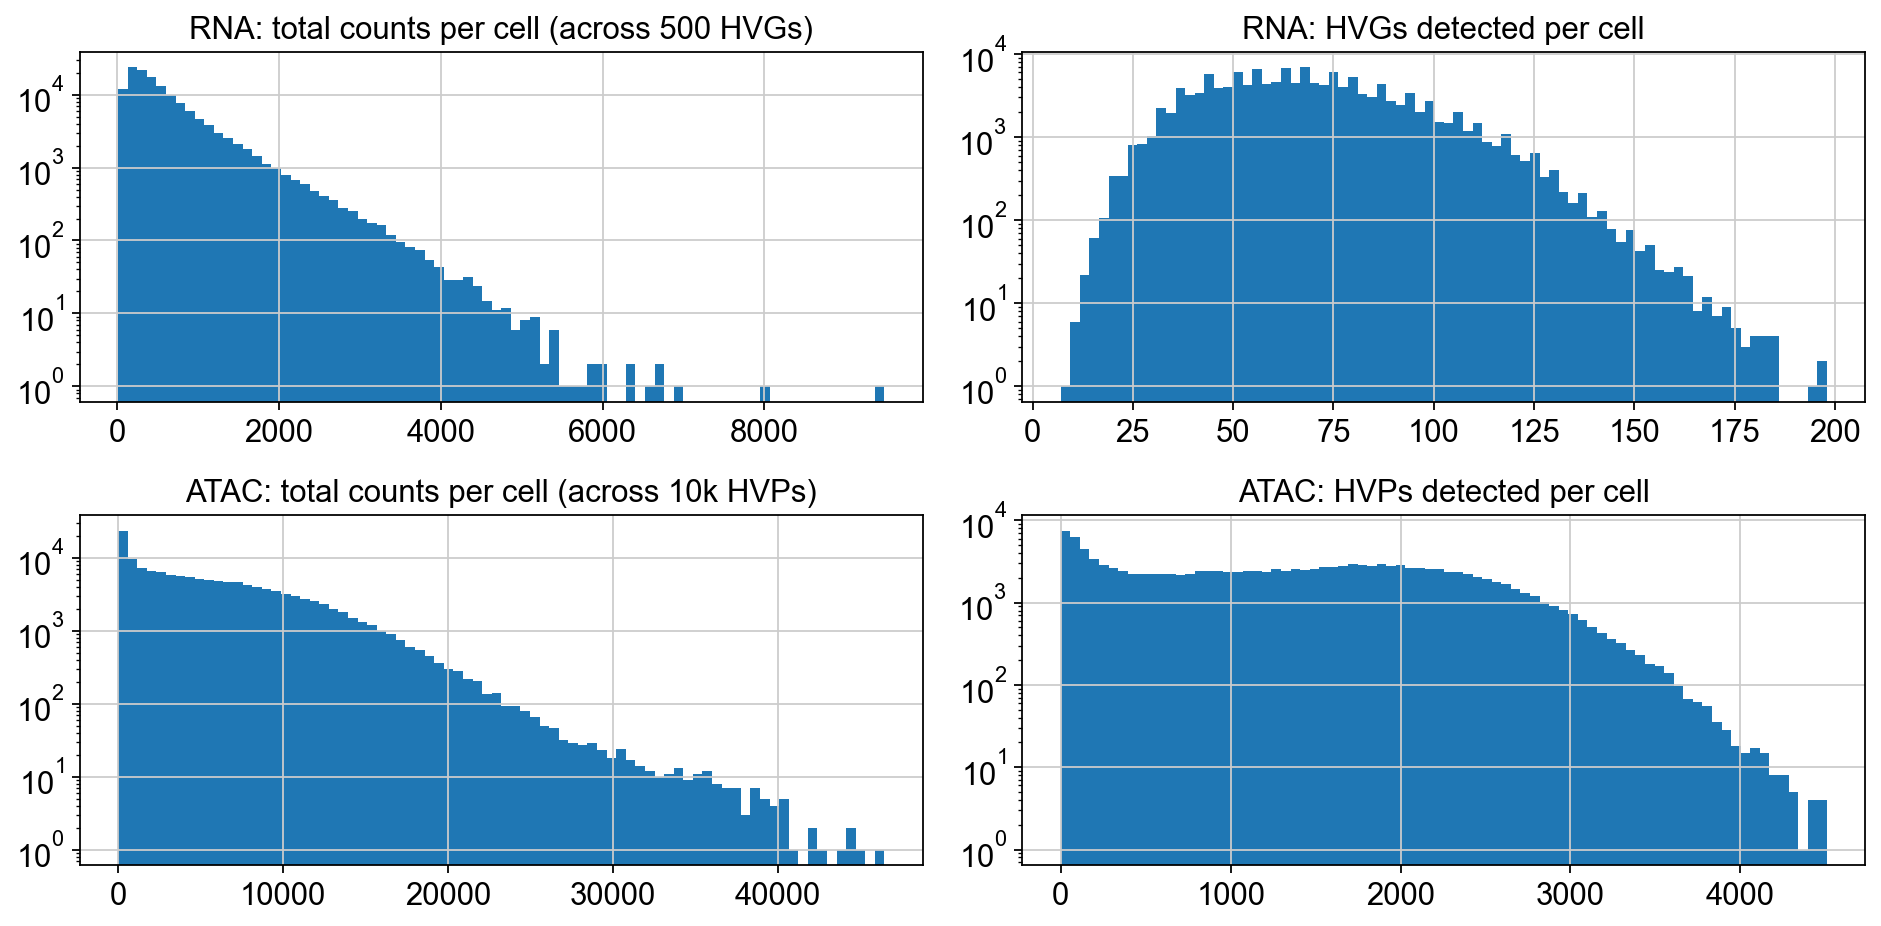

In [5]:
def _sums_per_cell(X):
    arr = X.sum(axis=1) if not sp.issparse(X) else np.asarray(X.sum(axis=1)).flatten()
    return np.asarray(arr).flatten()

def _detected_per_cell(X):
    arr = (X > 0).sum(axis=1) if not sp.issparse(X) else np.asarray((X > 0).sum(axis=1)).flatten()
    return np.asarray(arr).flatten()

rna_total    = _sums_per_cell(rna.X)
rna_detected = _detected_per_cell(rna.X)
atac_total    = _sums_per_cell(atac.X)
atac_detected = _detected_per_cell(atac.X)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes[0, 0].hist(rna_total,    bins=80); axes[0, 0].set_title("RNA: total counts per cell (across 500 HVGs)")
axes[0, 1].hist(rna_detected, bins=80); axes[0, 1].set_title("RNA: HVGs detected per cell")
axes[1, 0].hist(atac_total,    bins=80); axes[1, 0].set_title("ATAC: total counts per cell (across 10k HVPs)")
axes[1, 1].hist(atac_detected, bins=80); axes[1, 1].set_title("ATAC: HVPs detected per cell")
for ax in axes.flat:
    ax.set_yscale("log")
plt.tight_layout()

print(f"RNA  median: total={np.median(rna_total):,.0f}, detected={np.median(rna_detected):.0f}")
print(f"ATAC median: total={np.median(atac_total):,.0f}, detected={np.median(atac_detected):.0f}")

## Stratified subsample for UMAP

Pick ~30k cells stratified by subclass. Same indices are used for the RNA and ATAC UMAPs so the two views are on the same cells.

In [6]:
rng = np.random.RandomState(0)
target = 30_000
per_type = max(1, target // rna.obs["cell_type"].nunique())
sample_idx = []
for _, group in rna.obs.groupby("cell_type", observed=True).groups.items():
    arr = np.asarray(group)
    k = min(per_type, len(arr))
    sample_idx.extend(rng.choice(arr, size=k, replace=False).tolist())
sample_idx = sorted(set(sample_idx))
# Map obs_names -> integer positions for fast slicing.
name_to_pos = {n: i for i, n in enumerate(rna.obs_names)}
pos_idx = [name_to_pos[n] for n in sample_idx]
print(f"sampled {len(pos_idx):,} of {rna.n_obs:,} cells")

sampled 24,875 of 138,118 cells


## RNA UMAP

Standard scRNA preprocessing on the 500 pre-selected HVGs: log-normalize â†’ scale â†’ PCA â†’ kNN â†’ UMAP.

In [7]:
rna_sub = rna[pos_idx].copy()
sc.pp.normalize_total(rna_sub, target_sum=1e4)
sc.pp.log1p(rna_sub)
sc.pp.scale(rna_sub, max_value=10)
sc.tl.pca(rna_sub, n_comps=min(50, rna_sub.n_vars - 1))
sc.pp.neighbors(rna_sub, n_neighbors=15)
sc.tl.umap(rna_sub)

c:\Users\timo\Repositories\bsc-screni\.pixi\envs\default\Lib\functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\timo\Repositories\bsc-screni\.pixi\envs\default\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


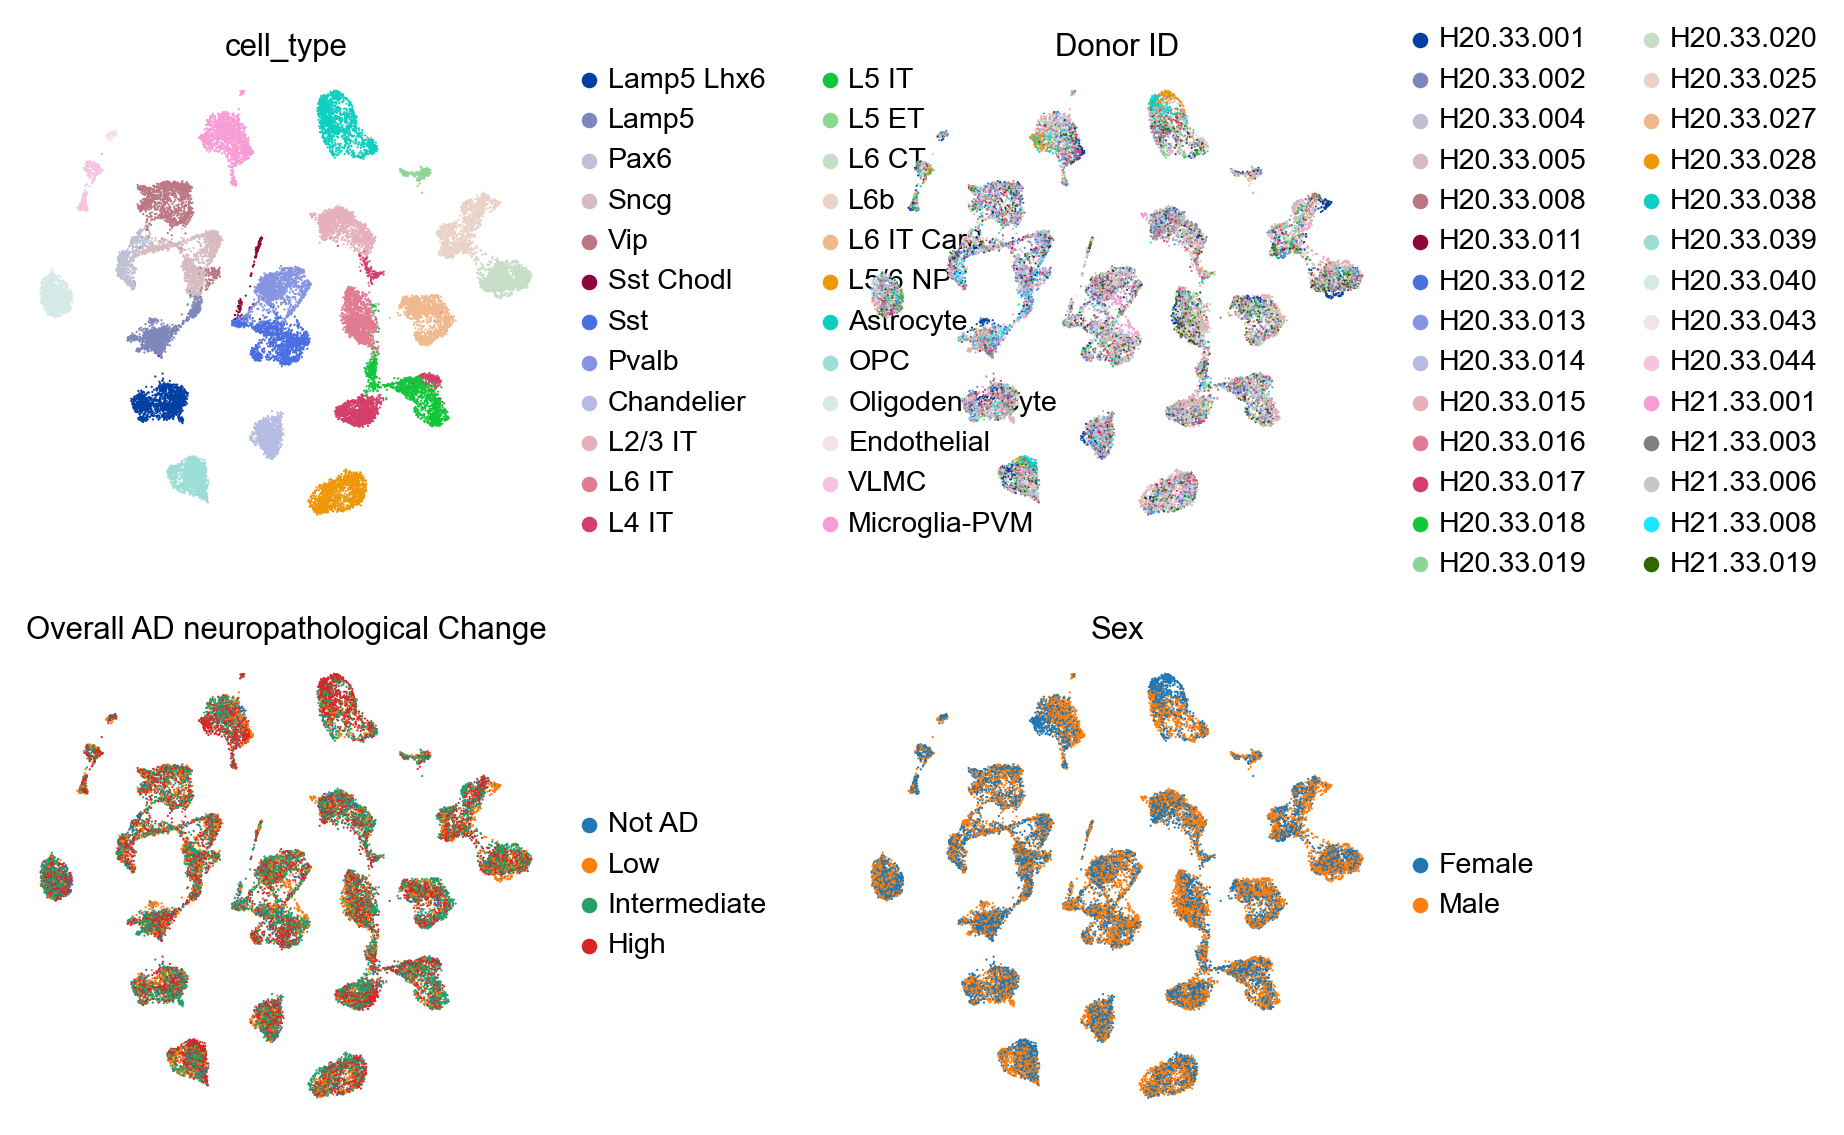

In [8]:
rna_colors = [c for c in ("cell_type", "Donor ID", "Overall AD neuropathological Change",
                          "Sex", "APOE4 Status") if c in rna_sub.obs.columns]
sc.pl.umap(rna_sub, color=rna_colors, ncols=2, frameon=False, wspace=0.4, size=4)

## ATAC UMAP

TF-IDF + LSI (Signac-style). The first LSI component typically tracks sequencing depth and is dropped before kNN/UMAP.

In [12]:
import muon as mu

atac_sub = atac[pos_idx].copy()
mu.atac.pp.tfidf(atac_sub, scale_factor=1e4)
mu.atac.tl.lsi(atac_sub, n_comps=50)
atac_sub.obsm["X_lsi_red"] = atac_sub.obsm["X_lsi"][:, 0:]
sc.pp.neighbors(atac_sub, use_rep="X_lsi_red", n_neighbors=15)
sc.tl.umap(atac_sub)

c:\Users\timo\Repositories\bsc-screni\.pixi\envs\default\Lib\site-packages\muon\_atac\preproc.py:94: RuntimeWarning: divide by zero encountered in divide
  n_peaks = dia_matrix((1.0 / n_peaks, 0), shape=(n_peaks.size, n_peaks.size))


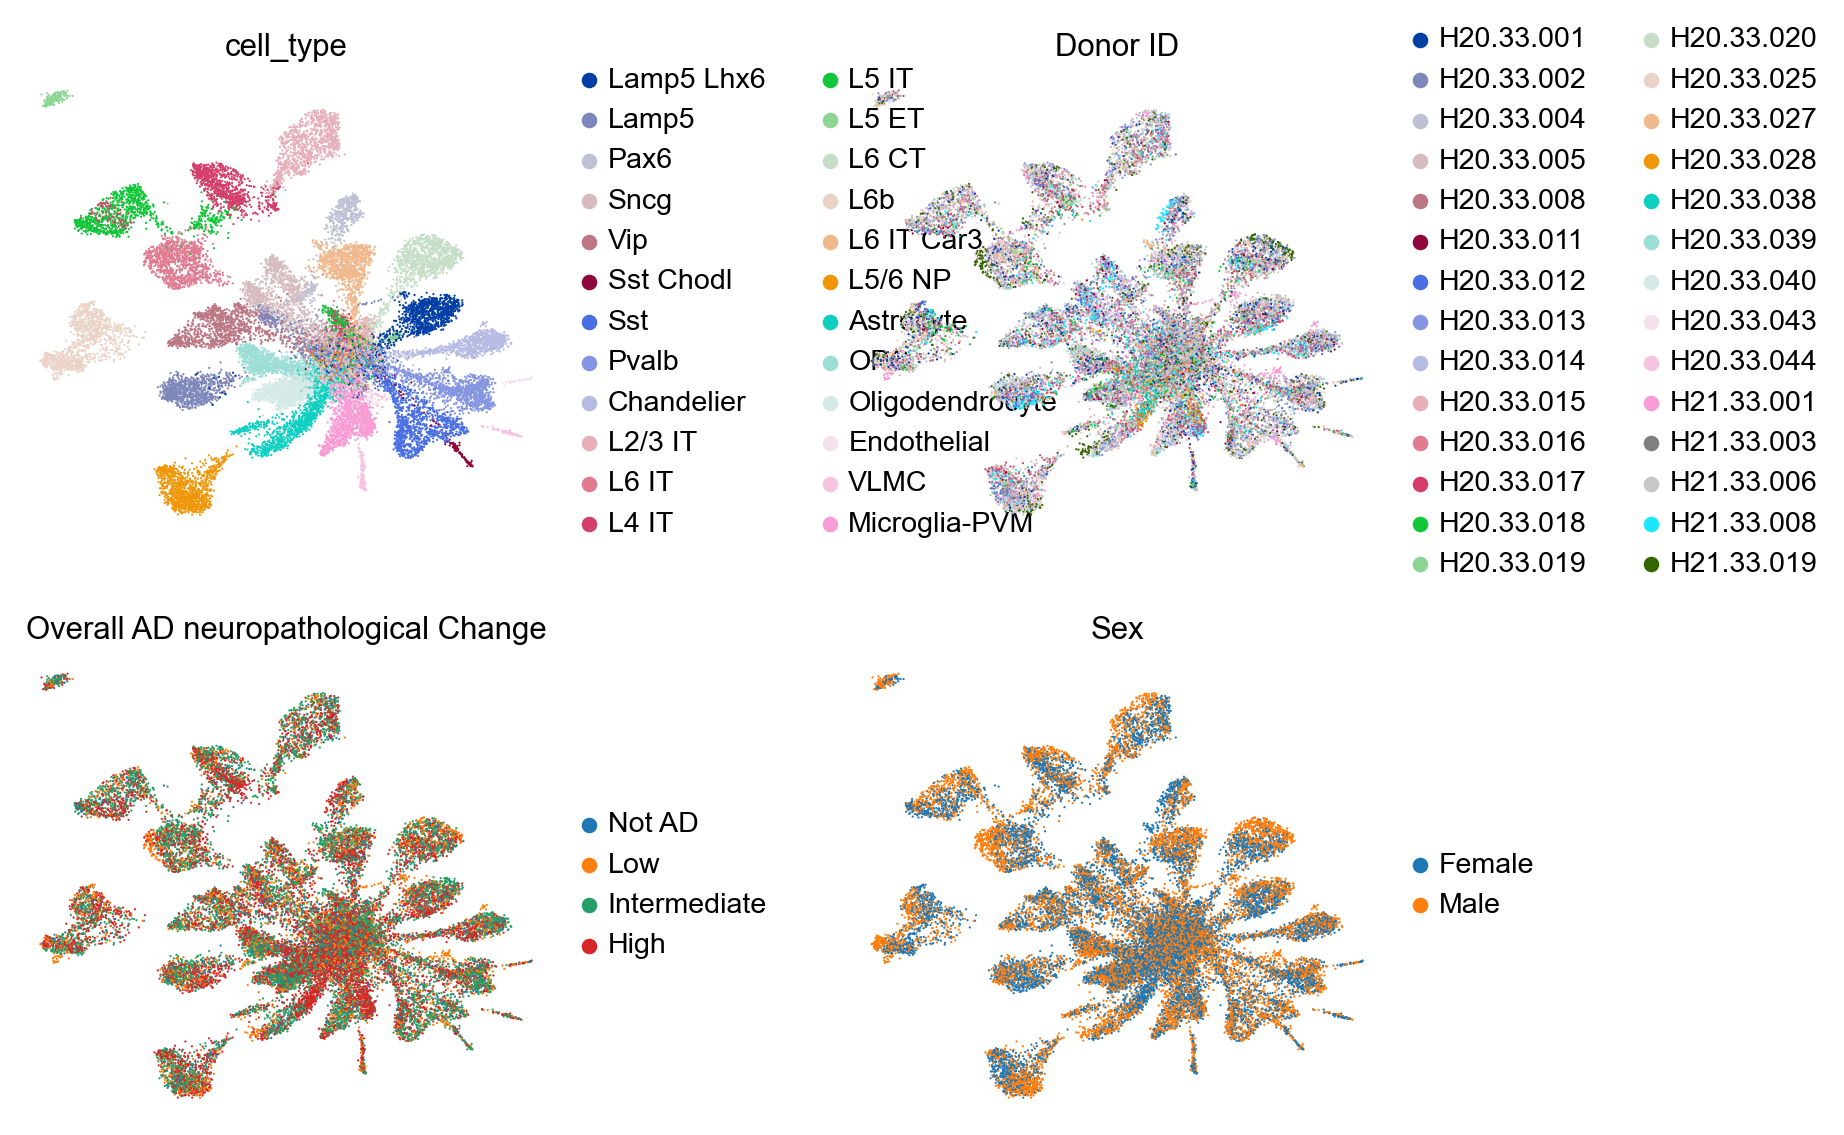

In [13]:
atac_colors = [c for c in ("cell_type", "Donor ID", "Overall AD neuropathological Change",
                           "Sex", "APOE4 Status") if c in atac_sub.obs.columns]
sc.pl.umap(atac_sub, color=atac_colors, ncols=2, frameon=False, wspace=0.4, size=4)

## Side-by-side: RNA vs ATAC UMAP

Same cells in both panels, embedded with independent feature sets. If subclass structure is similar across the two panels, the HVGs and HVPs capture concordant biology.

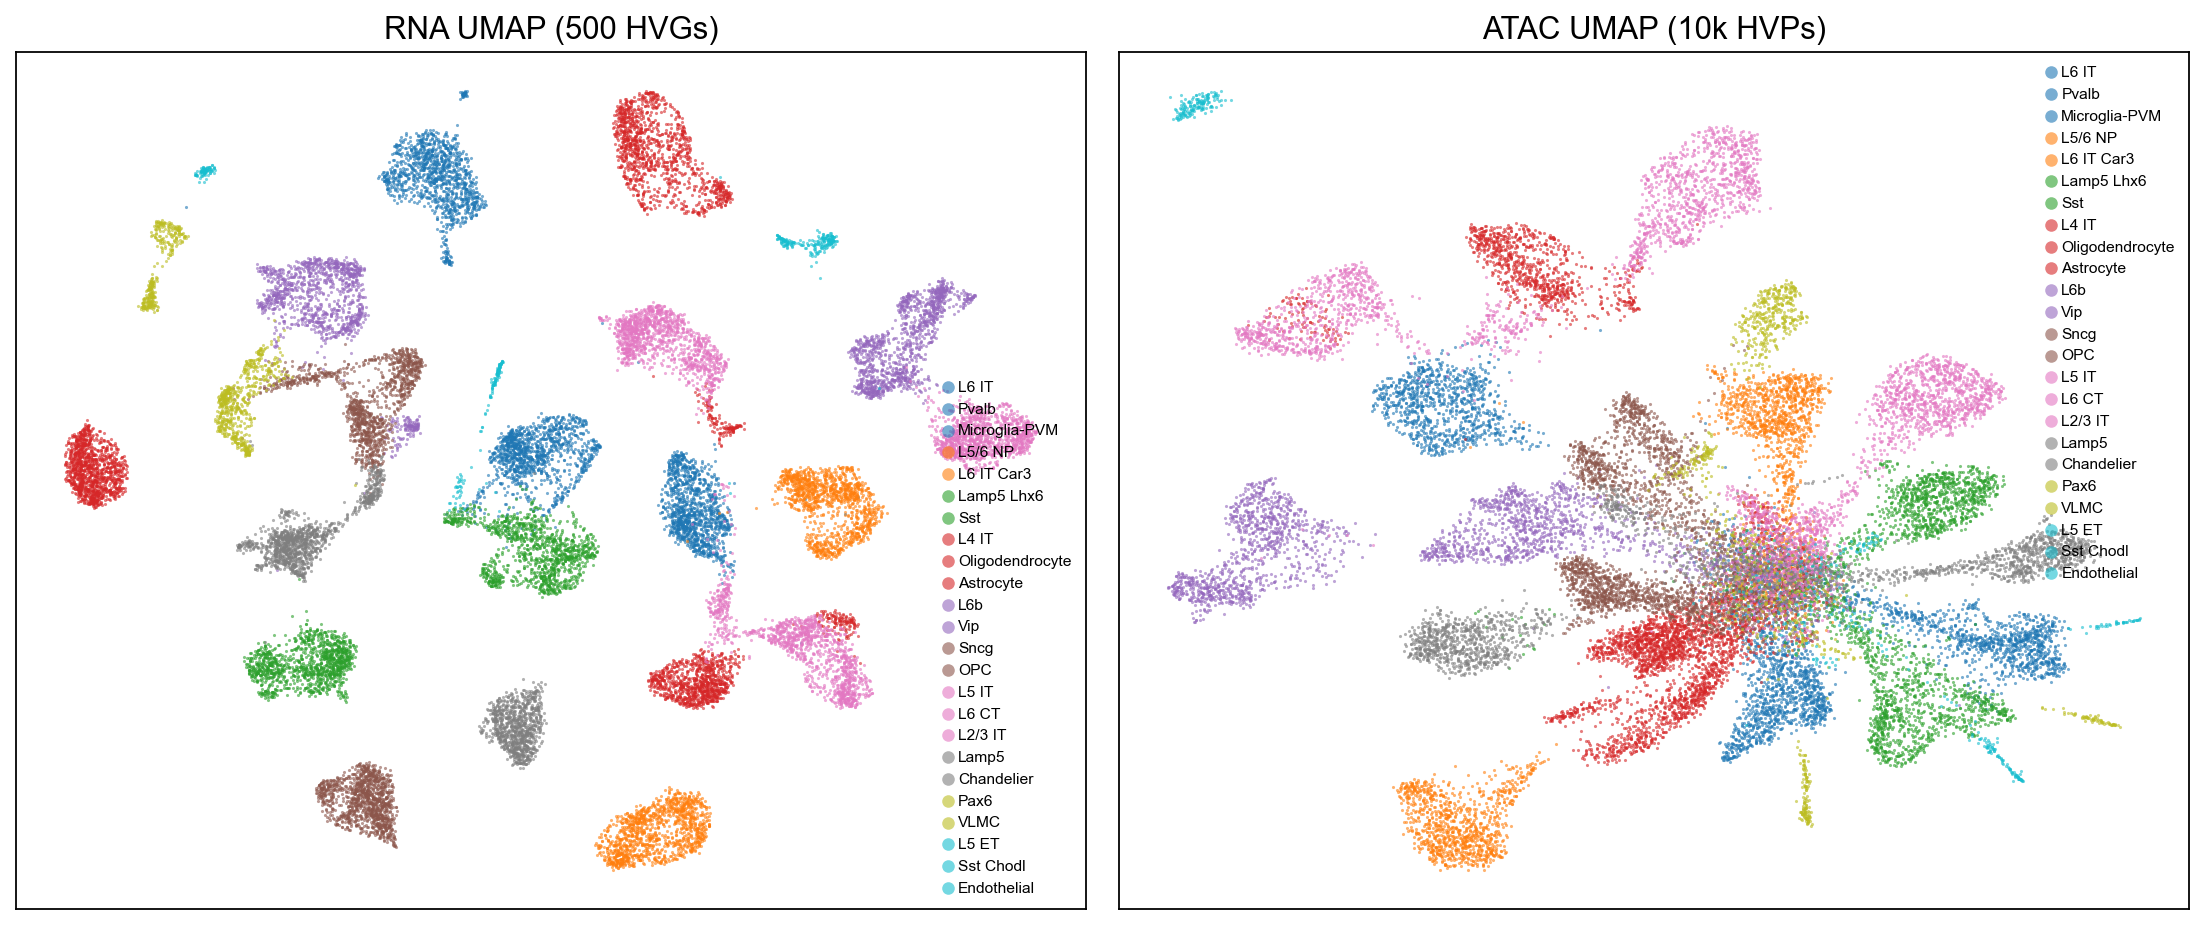

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, sub, title in [(axes[0], rna_sub,  "RNA UMAP (500 HVGs)"),
                       (axes[1], atac_sub, "ATAC UMAP (10k HVPs)")]:
    coords = sub.obsm["X_umap"]
    cts = sub.obs["cell_type"].astype(str)
    top = cts.value_counts().head(30).index
    palette = plt.cm.tab10(np.linspace(0, 1, len(top)))
    for ct, c in zip(top, palette):
        m = (cts == ct).values
        ax.scatter(coords[m, 0], coords[m, 1], s=2, c=[c], label=ct, alpha=0.6, linewidths=0)
    other = ~cts.isin(top)
    if other.any():
        ax.scatter(coords[other.values, 0], coords[other.values, 1],
                   s=1, c="lightgray", alpha=0.3, label="other")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)
    ax.legend(markerscale=4, loc="best", fontsize=7, frameon=False)
plt.tight_layout()

## What to check

- **Subclass structure**: panels colored by `cell_type` should show coherent clusters. Microglia / Astrocyte / Oligodendrocyte are usually the most distinct in cortical multiome.
- **Donor mixing**: panels colored by `Donor ID` should show donors mixed within each cluster (i.e. clusters are biological, not batches). Excessive donor separation within a single subclass suggests donor batch effects that may want explicit correction for some sub-questions.
- **AD signal**: ADNC / Cognitive Status panels won't show clean clusters (the disease signal is subtle and spread across cells); look for shifts in density within subclusters.
- **RNA vs ATAC concordance**: if the side-by-side coloring by `cell_type` looks broadly similar, the two modalities are picking up the same cells in the same way â€” a good sanity check on the WNN integration that produced these h5ads.